In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# ── Grafik stili ayarları ──────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

# ── Numpy yazdırma hassasiyeti ─────────────────────────────────────────────
np.set_printoptions(precision=4, suppress=True)

print('✅ Tüm kütüphaneler başarıyla yüklendi.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi.
   NumPy  : 2.0.2
   Pandas : 2.2.2


In [ ]:
# Veriyi oku
df = pd.read_csv('datam.csv')

print("📊 Veri Setinin Boyutu (Shape):", df.shape)
print("\n📋 İlk 5 Satır:")
print(df.head())

print("\n🔍 Eksik Değer Kontrolü:")
print(df.isnull().sum())

print("\n📈 İstatistiksel Özet:")
print(df.describe().round(2))

📊 Veri Setinin Boyutu (Shape): (50, 2)

📋 İlk 5 Satır:
       Weight      Height
0   69.963210   96.644532
1  116.057145  196.156340
2   98.559515  145.862047
3   87.892679  121.157923
4   52.481491   68.971292

🔍 Eksik Değer Kontrolü:
Weight    0
Height    0
dtype: int64

📈 İstatistiksel Özet:
       Weight  Height
count   50.00   50.00
mean    75.67  111.47
std     23.11   39.49
min     41.65   68.97
25%     54.70   79.97
50%     74.88   98.82
75%     91.99  129.71
max    117.59  202.66


In [ ]:
X = df[['Height']].values
y = df['Weight'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Eğitim Seti: {X_train.shape} | Test Seti: {X_test.shape}")

Eğitim Seti: (40, 1) | Test Seti: (10, 1)


In [ ]:
degrees = [1, 2, 3, 4, 5]
models = {}
results = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=True),
        LinearRegression()
    )

    # Modeli eğit
    model.fit(X_train, y_train)
    models[degree] = model

    # Tahminler
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrikler
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results.append({
        'Derece': degree,
        'Train R²': r2_train,
        'Test R²': r2_test,
        'Test RMSE': rmse_test
    })

results_df = pd.DataFrame(results)
print("🏆 Model Performans Karşılaştırma Tablosu:")
print(results_df.round(4).to_string(index=False))

🏆 Model Performans Karşılaştırma Tablosu:
 Derece  Train R²  Test R²  Test RMSE
      1    0.9364   0.8638     6.5174
      2    0.9713   0.9438     4.1857
      3    0.9717   0.9514     3.8921
      4    0.9718   0.9509     3.9120
      5    0.9722   0.9533     3.8151


In [ ]:
print('🔄 5-Fold Cross-Validation Süreci:')
print('─' * 45)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=True),
        LinearRegression()
    )
    # Skorları hesapla (Negatif MSE döndüğü için eksiyle çarpıyoruz)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)

    print(f"Derece {degree} -> Ortalama RMSE: {rmse_scores.mean():.4f} (+/- Std: {rmse_scores.std():.4f})")

🔄 5-Fold Cross-Validation Süreci:
─────────────────────────────────────────────
Derece 1 -> Ortalama RMSE: 6.4317 (+/- Std: 0.9050)
Derece 2 -> Ortalama RMSE: 4.0912 (+/- Std: 1.1944)
Derece 3 -> Ortalama RMSE: 4.1505 (+/- Std: 1.1349)
Derece 4 -> Ortalama RMSE: 4.2754 (+/- Std: 1.0955)
Derece 5 -> Ortalama RMSE: 4.2109 (+/- Std: 1.0499)


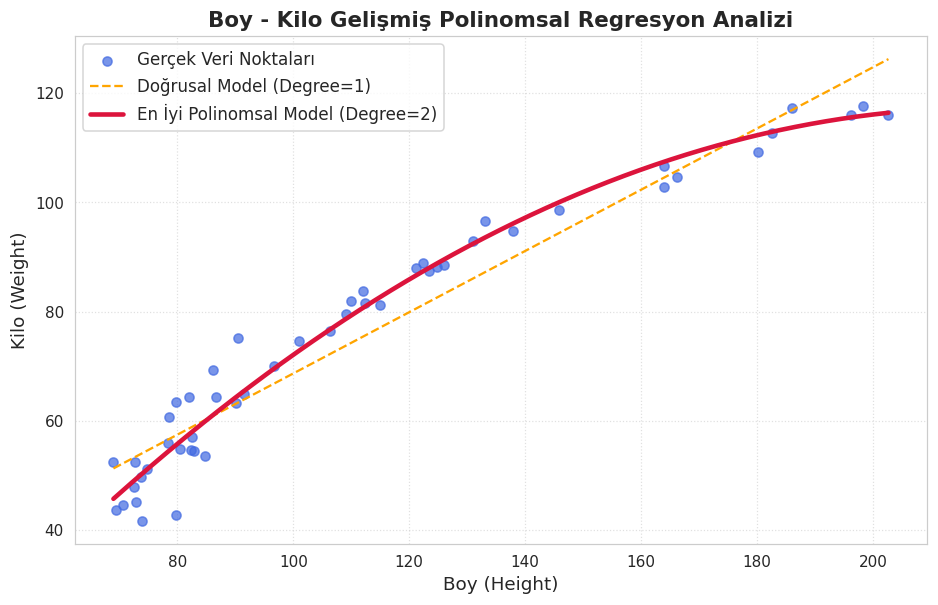

In [ ]:
# Metriklere göre en iyi dereceyi seçiyoruz
best_degree = 2
best_model = models[best_degree]

# Grafik çizimi
plt.figure(figsize=(10, 6))

# 1. Gerçek verileri saçılım grafiği yap
plt.scatter(X, y, color='royalblue', alpha=0.7, label='Gerçek Veri Noktaları')

# 2. Pürüzsüz bir eğri çizmek için X eksenini sıralı olarak simüle et
X_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

# Doğrusal Çizgi (Derece 1)
plt.plot(X_line, models[1].predict(X_line), color='orange', linestyle='--', label='Doğrusal Model (Degree=1)')

# En İyi Polinomsal Eğri (Derece 2)
plt.plot(X_line, best_model.predict(X_line), color='crimson', linewidth=3, label=f'En İyi Polinomsal Model (Degree={best_degree})')

plt.title('Boy - Kilo Gelişmiş Polinomsal Regresyon Analizi', fontsize=14, fontweight='bold')
plt.xlabel('Boy (Height)', fontsize=12)
plt.ylabel('Kilo (Weight)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
lr_step = best_model.named_steps['linearregression']
pf_step = best_model.named_steps['polynomialfeatures']

intercept = lr_step.intercept_
coeffs = lr_step.coef_
feat_names = pf_step.get_feature_names_out(['Height'])

print("📝 Modelin Öğrendiği Matematiksel Formül:")
equation = f"Weight = {intercept:.4f}"
for coeff, name in zip(coeffs[1:], feat_names[1:]): # bias terimini geçiyoruz
    equation += f" + ({coeff:.4f} * {name})"
print(equation)

📝 Modelin Öğrendiği Matematiksel Formül:
Weight = -34.4502 + (1.3781 * Height) + (-0.0031 * Height^2)
